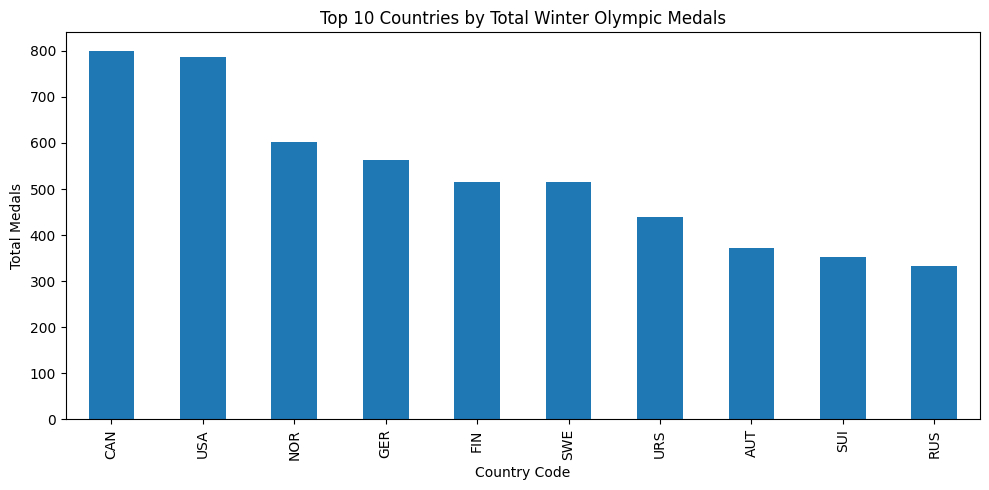

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

medals = pd.read_csv("winter_olympics_medals.csv")
pop = pd.read_csv("populations.csv")

winter_medals = medals[medals["medal"].notna()].copy()

medal_counts = winter_medals.groupby("noc").size().sort_values(ascending=False)
top10_total = medal_counts.head(10)

plt.figure(figsize=(10,5))
top10_total.plot(kind="bar")
plt.title("Top 10 Countries by Total Winter Olympic Medals")
plt.ylabel("Total Medals")
plt.xlabel("Country Code")
plt.tight_layout()
plt.show()


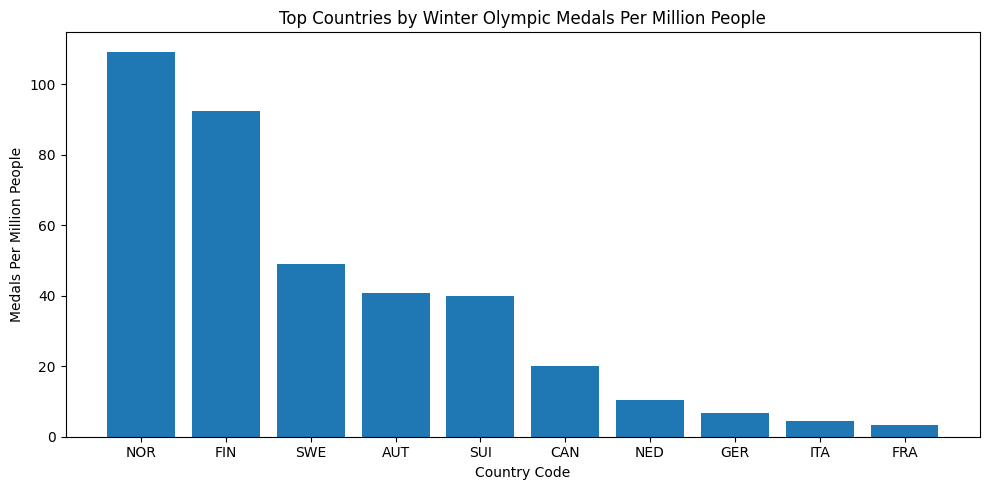

In [3]:
# use 2023 population as the closest recent comparison
pop_2023 = pop[["Country Code", "2023"]].copy()
pop_2023.columns = ["noc", "population"]

country_map = {
    "USA": "USA",
    "CAN": "CAN",
    "NOR": "NOR",
    "SWE": "SWE",
    "FIN": "FIN",
    "GER": "DEU",
    "FRA": "FRA",
    "ITA": "ITA",
    "SUI": "CHE",
    "AUT": "AUT",
    "NED": "NLD"
}

medal_df = medal_counts.reset_index()
medal_df.columns = ["noc", "medals"]
medal_df["pop_code"] = medal_df["noc"].map(country_map)

merged = medal_df.merge(pop_2023, left_on="pop_code", right_on="noc", how="left", suffixes=("_medal", "_pop"))
merged["medals_per_million"] = merged["medals"] / (merged["population"] / 1_000_000)

per_million = merged.dropna(subset=["medals_per_million"]).sort_values("medals_per_million", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(per_million["noc_medal"], per_million["medals_per_million"])
plt.title("Top Countries by Winter Olympic Medals Per Million People")
plt.ylabel("Medals Per Million People")
plt.xlabel("Country Code")
plt.tight_layout()
plt.show()


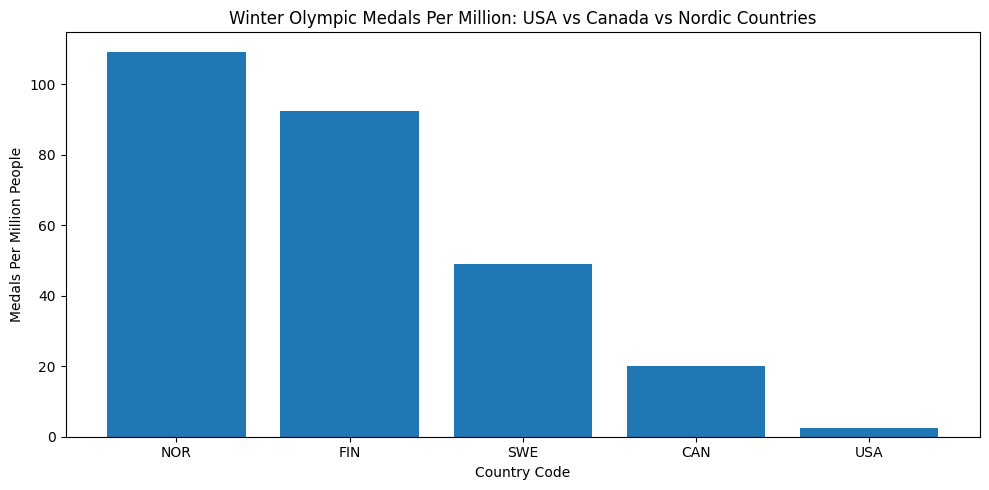

In [4]:
focus = merged[merged["noc_medal"].isin(["USA", "CAN", "NOR", "SWE", "FIN"])].copy()
focus = focus.sort_values("medals_per_million", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(focus["noc_medal"], focus["medals_per_million"])
plt.title("Winter Olympic Medals Per Million: USA vs Canada vs Nordic Countries")
plt.ylabel("Medals Per Million People")
plt.xlabel("Country Code")
plt.tight_layout()
plt.show()


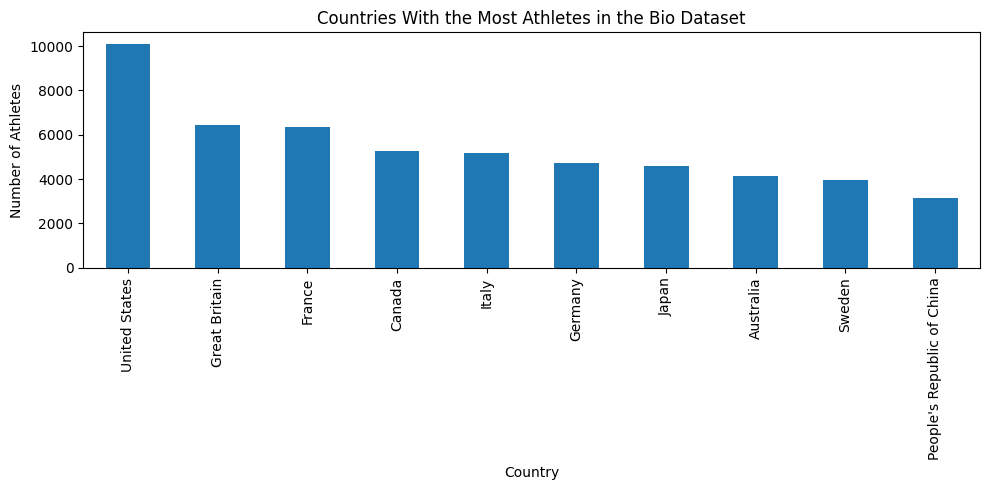

In [5]:
bios = pd.read_csv("bios.csv")

athletes_by_country = bios["NOC"].value_counts().head(10)

plt.figure(figsize=(10,5))
athletes_by_country.plot(kind="bar")
plt.title("Countries With the Most Athletes in the Bio Dataset")
plt.ylabel("Number of Athletes")
plt.xlabel("Country")
plt.tight_layout()
plt.show()
